<a href="https://colab.research.google.com/github/Ranger3560/IMDB-Sentiment-Visualisation/blob/main/IMDB_Sentiment_Visualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Load dataset (assumes CSV with columns: review, sentiment)
df = pd.read_csv("/content/sample_data/IMDB Dataset.csv")

# Basic cleaning (optional)
df = df.dropna()
df['review'] = df['review'].str.lower()

# Encode labels (positive=1, negative=0)
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# Split data
X_train, X_val, y_train, y_val = train_test_split(
    df['review'], df['sentiment'], test_size=0.2, random_state=42
)

# Build pipeline
model = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words='english', max_features=5000)),
    ("clf", LogisticRegression(max_iter=1000))
])

# Train
model.fit(X_train, y_train)

# Validate
y_pred = model.predict(X_val)
print(classification_report(y_val, y_pred))

# -------------------------
# Create a dummy test.csv if it doesn't exist for demonstration purposes
# In a real scenario, you would load your actual test dataset here.
import os
if not os.path.exists("test.csv"):
    # Using a small portion of the original dataset for demonstration
    df_test_sample = df.sample(n=100, random_state=42)[['review']]
    df_test_sample.to_csv("test.csv", index=False)
    print("Created a dummy 'test.csv' for demonstration.")

# Predict on TEST DATASET
# -------------------------

test_df = pd.read_csv("test.csv")  # must contain 'review' column
test_df['review'] = test_df['review'].str.lower()

# Predict
test_predictions = model.predict(test_df['review'])

# Convert back to labels
test_df['predicted_sentiment'] = pd.Series(test_predictions).map({1: 'positive', 0: 'negative'})

# Save results
test_df.to_csv("predictions.csv", index=False)

print(test_df.head())

              precision    recall  f1-score   support

           0       0.90      0.87      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

                                              review predicted_sentiment
0  i really liked this summerslam due to the look...            negative
1  not many television shows appeal to quite as m...            positive
2  the film quickly gets to a major chase scene w...            negative
3  jane austen would definitely approve of this o...            positive
4  expectations were somewhat high for me when i ...            negative


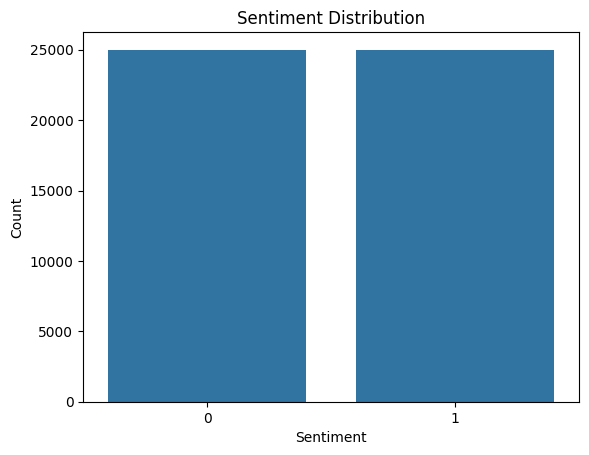

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

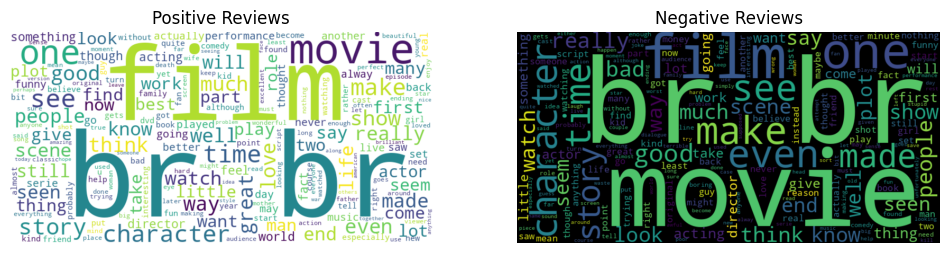

In [5]:
from wordcloud import WordCloud

# Positive reviews
pos_text = " ".join(df[df['sentiment'] == 1]['review'])
neg_text = " ".join(df[df['sentiment'] == 0]['review'])

# Generate word clouds
wc_pos = WordCloud(width=800, height=400, background_color='white').generate(pos_text)
wc_neg = WordCloud(width=800, height=400, background_color='black').generate(neg_text)

# Plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(wc_pos, interpolation='bilinear')
plt.title("Positive Reviews")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(wc_neg, interpolation='bilinear')
plt.title("Negative Reviews")
plt.axis("off")

plt.show()

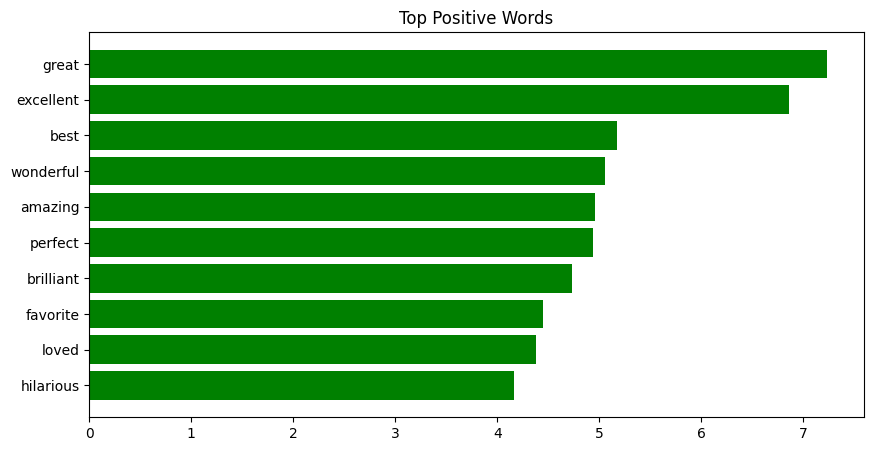

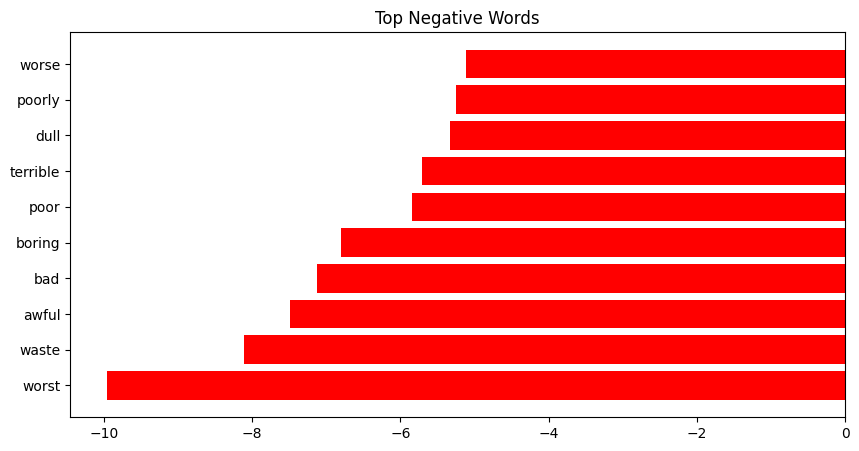

In [6]:
import numpy as np

# Get feature names and coefficients
feature_names = model.named_steps['tfidf'].get_feature_names_out()
coefficients = model.named_steps['clf'].coef_[0]

# Top words
top_pos = np.argsort(coefficients)[-10:]
top_neg = np.argsort(coefficients)[:10]

plt.figure(figsize=(10,5))

plt.barh([feature_names[i] for i in top_pos], coefficients[top_pos], color='green')
plt.title("Top Positive Words")
plt.show()

plt.figure(figsize=(10,5))
plt.barh([feature_names[i] for i in top_neg], coefficients[top_neg], color='red')
plt.title("Top Negative Words")
plt.show()

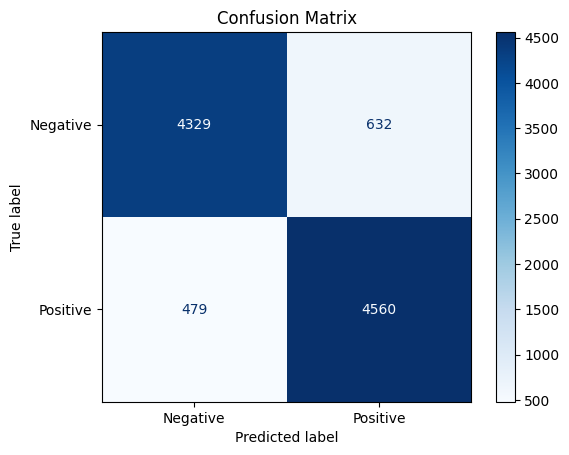

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

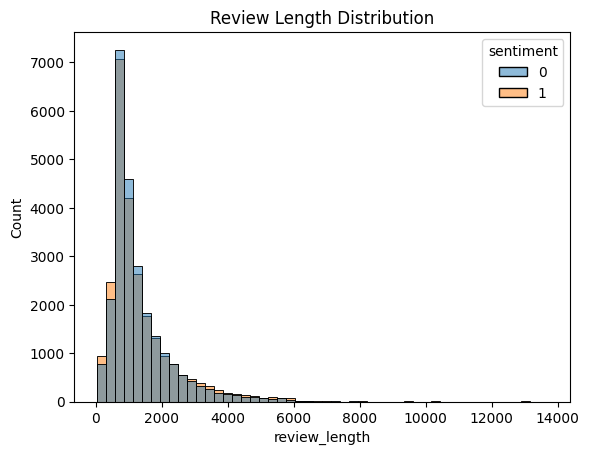

In [8]:
df['review_length'] = df['review'].apply(len)

sns.histplot(data=df, x='review_length', hue='sentiment', bins=50)
plt.title("Review Length Distribution")
plt.show()